In [1]:
import os
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

In [2]:
path_to_db_local = 'telecomm_csi.db'
path_to_db_platform = '/datasets/telecomm_csi.db'
path_to_db = None

if os.path.exists(path_to_db_local):
    path_to_db = path_to_db_local
elif os.path.exists(path_to_db_platform):
    path_to_db = path_to_db_platform
else:
    raise Exception('Файл с базой данных SQLite не найден!')

if path_to_db:
    engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [3]:
query = """
SELECT u.user_id,
       u.lt_day,
       CASE
           WHEN u.lt_day > 365 THEN 'старый'
           WHEN u.lt_day <= 365 THEN 'новый'
       END AS is_new,
       u.age,
       CASE 
           WHEN u.gender_segment = 1 THEN 'женщина'
           WHEN u.gender_segment = 0 THEN 'мужчина'
           ELSE 'n/a'
       END AS gender,
       u.os_name,
       u.cpe_type_name,
       l.country,
       l.city,
       asg.title AS age_segment,
       tsg.title AS traffic_segment,
       lsg.title AS lifetime_segment,
       u.nps_score,
       CASE
           WHEN u.nps_score>=9 AND u.nps_score<=10 THEN 'сторонники'
           WHEN u.nps_score>=7 AND u.nps_score<=8 THEN 'нейтралы'
           WHEN u.nps_score>=0 AND u.nps_score<=6 THEN 'критики'
       END AS nps_group
FROM user AS u LEFT JOIN location as l ON u.location_id=l.location_id
          LEFT JOIN age_segment AS asg ON u.age_gr_id=asg.age_gr_id
          LEFT JOIN lifetime_segment AS lsg ON u.lt_gr_id=lsg.lt_gr_id
          LEFT JOIN traffic_segment AS tsg ON u.tr_gr_id=tsg.tr_gr_id
"""

In [11]:
df = pd.read_sql(query, engine)
df.head()

,user_id,lt_day,is_new,age,gender,os_name,cpe_type_name,country,city,age_segment,traffic_segment,lifetime_segment,nps_score,nps_group
0,A001A2,2320,старый,45.0,женщина,ANDROID,SMARTPHONE,Россия,Уфа,05 45-54,04 1-5,08 36+,10,сторонники
1,A001WF,2344,старый,53.0,мужчина,ANDROID,SMARTPHONE,Россия,Киров,05 45-54,04 1-5,08 36+,10,сторонники
2,A003Q7,467,старый,57.0,мужчина,ANDROID,SMARTPHONE,Россия,Москва,06 55-64,08 20-25,06 13-24,10,сторонники
3,A004TB,4190,старый,44.0,женщина,IOS,SMARTPHONE,Россия,РостовнаДону,04 35-44,03 0.1-1,08 36+,10,сторонники
4,A004XT,1163,старый,24.0,мужчина,ANDROID,SMARTPHONE,Россия,Рязань,02 16-24,05 5-10,08 36+,10,сторонники


In [5]:
#проверим, есть ли пропуски в переменной gender
df.gender.isna().sum()

0

In [12]:
#заполним пропуски в переменной возраст
df.age=df.age.fillna('n/a')

In [7]:
#преобразуем переменные age_segment, traffic_segment, lifetime_segment:
df['age_segment']=df['age_segment'].apply(lambda x: x[3:])
df['traffic_segment']=df['traffic_segment'].apply(lambda x: x[3:])
df['lifetime_segment']=df['lifetime_segment'].apply(lambda x: x[3:])
df.head()

,user_id,lt_day,is_new,age,gender,os_name,cpe_type_name,country,city,age_segment,traffic_segment,lifetime_segment,nps_score,nps_group
0,A001A2,2320,старый,45.0,женщина,ANDROID,SMARTPHONE,Россия,Уфа,45-54,1-5,36+,10,сторонники
1,A001WF,2344,старый,53.0,мужчина,ANDROID,SMARTPHONE,Россия,Киров,45-54,1-5,36+,10,сторонники
2,A003Q7,467,старый,57.0,мужчина,ANDROID,SMARTPHONE,Россия,Москва,55-64,20-25,13-24,10,сторонники
3,A004TB,4190,старый,44.0,женщина,IOS,SMARTPHONE,Россия,РостовнаДону,35-44,0.1-1,36+,10,сторонники
4,A004XT,1163,старый,24.0,мужчина,ANDROID,SMARTPHONE,Россия,Рязань,16-24,5-10,36+,10,сторонники


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502493 entries, 0 to 502492
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           502493 non-null  object
 1   lt_day            502493 non-null  int64 
 2   is_new            502493 non-null  object
 3   age               502493 non-null  object
 4   gender            502493 non-null  object
 5   os_name           502493 non-null  object
 6   cpe_type_name     502493 non-null  object
 7   country           502493 non-null  object
 8   city              502493 non-null  object
 9   age_segment       502493 non-null  object
 10  traffic_segment   502493 non-null  object
 11  lifetime_segment  502493 non-null  object
 12  nps_score         502493 non-null  int64 
 13  nps_group         502493 non-null  object
dtypes: int64(2), object(12)
memory usage: 53.7+ MB


In [9]:
df.to_csv('telecomm_csi_tableau.csv', index=False)

Файл готов. Ссылка на дэшборд:

https://public.tableau.com/views/-2_16940307750160/sheet13?:language=en-US&publish=yes&:display_count=n&:origin=viz_share_link

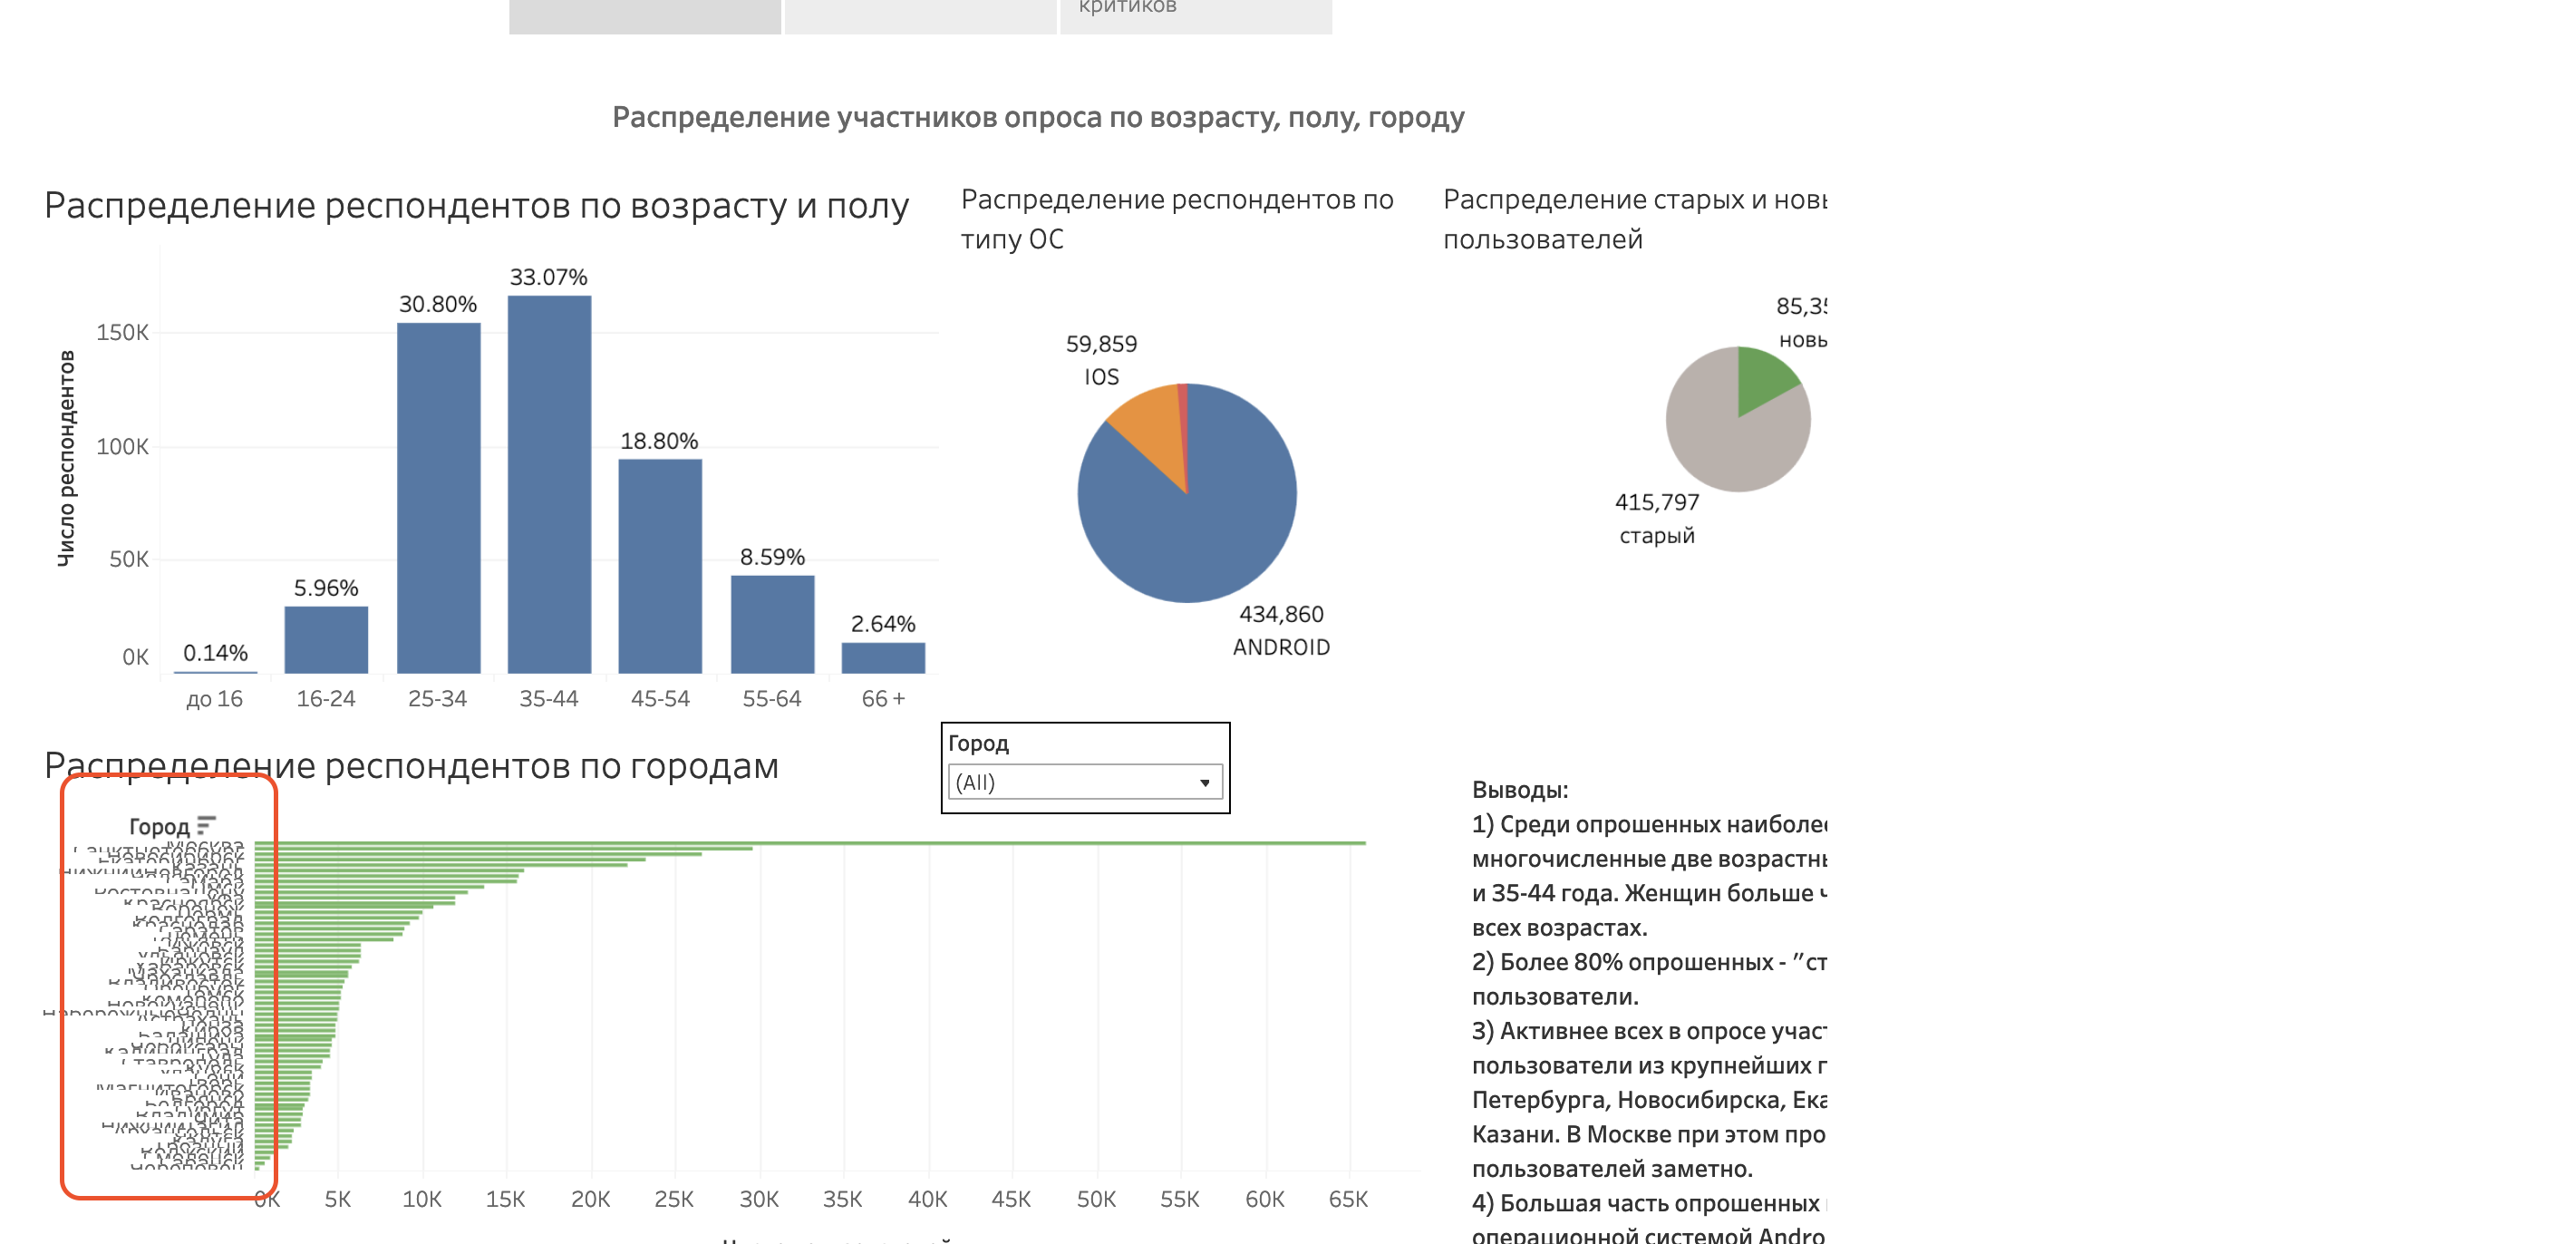